# Notebook 7 — Big O, Big Ω, Big Θ

**Covers Chapter 3 §3.2, §3.3, §3.6.** The formal half of complexity. We define `O(−)` precisely, prove the propositions about how it behaves, then add `Ω` (lower bound) and `Θ` (tight bound).

## What you'll be able to do by the end

- State the formal definitions of *dominates*, *eventually dominates*, `O(f)`, `Ω(f)`, `Θ(f)`.
- Prove that two functions are or aren't in the same `O(−)` class using the definition.
- Apply Propositions 8, 9, 10, 11, 12 to simplify expressions (e.g. drop lower-order terms).
- Solve exercises 21, 22, 26, 27, 28, 29.

## Visual aid

We use `matplotlib` to plot growth rates, so you can *see* why `O(n²)` overtakes `100n` eventually, why `log n` sits below `n`, and why `2ⁿ` blows past everything. The visual is half the intuition.

In [1]:
import sys
from pathlib import Path

for candidate in [Path.cwd(), Path.cwd() / 'notebooks', Path.cwd().parent / 'notebooks']:
    if (candidate / 'while_lang.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise ImportError('could not find while_lang.py')

import math
import matplotlib.pyplot as plt
import numpy as np
from while_lang import count_steps, step_growth

# Standard plotting setup — wide aspect, readable axes.
plt.rcParams.update({'figure.figsize': (10, 5), 'font.size': 11})
print('imports OK')

imports OK


## §1. Why we need formal asymptotic analysis

From §3.2: the practical concern is that running a program **takes time**, and *how much time* matters:

- A safety-critical autopilot needs the answer in milliseconds.
- A data-pipeline job needs the answer before tomorrow's morning meeting.
- A research experiment needs the answer before the conference deadline.

What ties these together: **what we care about is how fast the running time grows as the input size grows.** A program that's slow on a 10-row input but stays slow on a 10-million-row input might be fine. A program that's fast on 10 rows but takes a year on 10 million rows is broken.

So we need:

1. **Functions** describing complexity. Inputs: real numbers (we're working asymptotically — exact integer counts are too detailed). Outputs: real numbers.
2. **A way to compare** two such functions to say "this one grows slower than that one."
3. **A way to ignore irrelevant differences** — constant factors, lower-order terms.

All three of these get formalised in §3.2 of the chapter.

## §2. Three increasingly liberal notions of "smaller"

### Definition 4 — `f` dominates `g`

`f` dominates `g` (or `f` is above `g`) means: **for all `x`, `f(x) ≥ g(x)`**.

This is the strict version. If `f` dominates `g`, then `g` is at least as good (or better) at every input.

**Problem with this:** programs we want to compare often *both* dominate at small inputs and *don't* dominate at large inputs. The definition is too strict to capture asymptotic behaviour.

### Definition 5 — `f` eventually dominates `g`

`f` eventually dominates `g` means: **there exists a `k` such that for all `x ≥ k`, `f(x) ≥ g(x)`**.

Translation: "after some point, `f` is always above `g`." This is what we usually mean when we say one function grows faster than another.

### Definition 6 — `g` is `O(f)`

Eventual domination is *almost* what we want, but it doesn't ignore constant factors. `100n` eventually dominates `n`, but they grow at the same *rate*. Big-O fixes this:

**`g` is `O(f)` iff there exists `c ∈ ℝ⁺` such that `c · f` eventually dominates `|g|`.**

Spelled out: there exist `c, k ∈ ℝ⁺` such that for all `x ≥ k`:

$$|g(x)| \le c \cdot f(x)$$

**Pronounced:** "g is big-O of f."

Now `100n` IS `O(n)` — pick `c = 100`, `k = 0`, and `100x ≤ 100 · x` trivially. The constant `100` got absorbed into `c`.

### Pictures

Visualising the difference between *dominates* and *eventually dominates*.

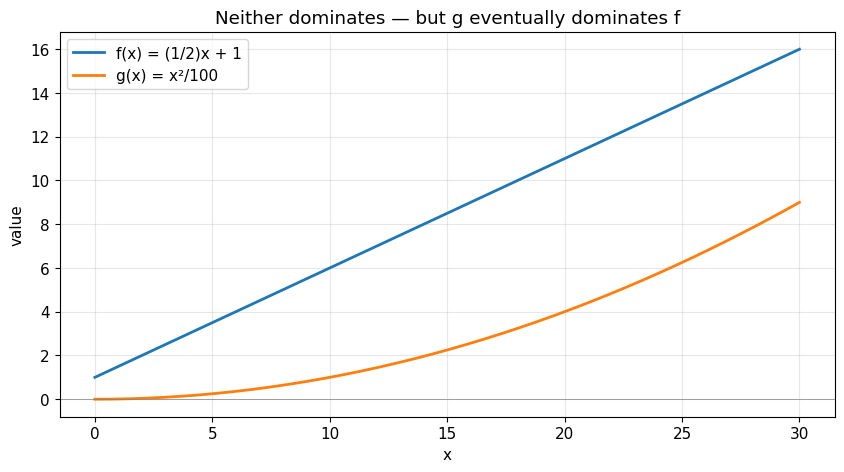

In [2]:
x = np.linspace(0, 30, 200)
f = 0.5 * x + 1
g = x ** 2 / 100   # crosses f around x ≈ 25 — for x < 25, f > g; for x > 25, g > f

plt.figure()
plt.plot(x, f, label='f(x) = (1/2)x + 1', linewidth=2)
plt.plot(x, g, label='g(x) = x²/100', linewidth=2)
plt.axhline(0, color='gray', linewidth=0.5)
plt.title('Neither dominates — but g eventually dominates f')
plt.xlabel('x'); plt.ylabel('value')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

# At x = 0, f(0) = 1 and g(0) = 0 — so g doesn't dominate f.
# But once x is big enough (~22.4), g overtakes f and stays above.
# That's eventual domination: "after some k, always above."

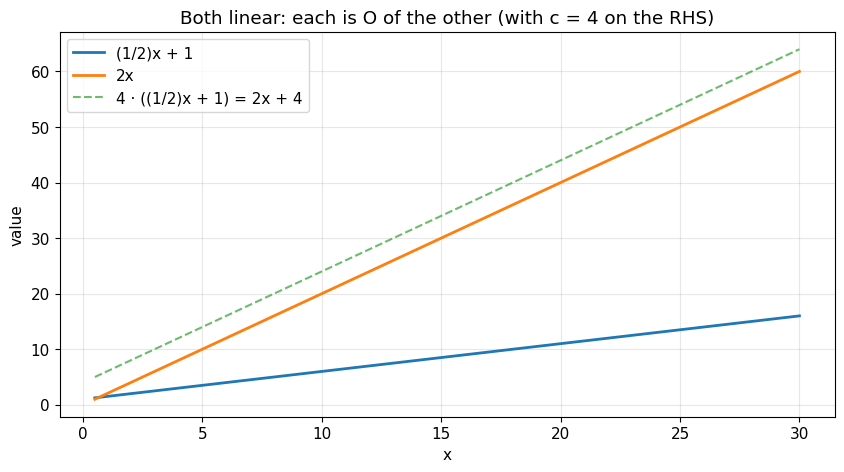

In [3]:
x = np.linspace(0.5, 30, 200)
f1 = (1/2) * x + 1
f2 = 2 * x          # g is O(f1) AND f1 is O(g) — same growth rate, different constants

plt.figure()
plt.plot(x, f1, label='(1/2)x + 1', linewidth=2)
plt.plot(x, f2, label='2x', linewidth=2)
plt.plot(x, 4 * f1, '--', label='4 · ((1/2)x + 1) = 2x + 4', linewidth=1.5, alpha=0.7)
plt.title('Both linear: each is O of the other (with c = 4 on the RHS)')
plt.xlabel('x'); plt.ylabel('value')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

# 2x is O((1/2)x + 1): take c = 4, then 4 · ((1/2)x + 1) = 2x + 4 ≥ 2x for all x ≥ 0.
# (1/2)x + 1 is O(2x): take c = 1, k = 2, then for x ≥ 2, (1/2)x + 1 ≤ 2x.
# So they're in the same O-class, even though one dominates pointwise.

### `x²` is NOT `O(x)`

The key separating example from §3.2.3. No matter what constant `c` you pick, `x²` eventually beats `c · x`.

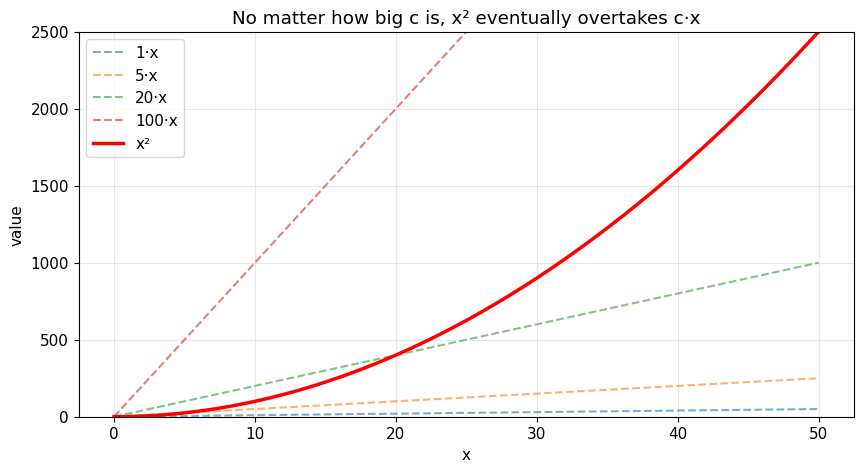

In [4]:
x = np.linspace(0, 50, 200)
h = x         # linear
h2 = x ** 2   # quadratic

plt.figure()
for c in [1, 5, 20, 100]:
    plt.plot(x, c * h, '--', label=f'{c}·x', alpha=0.6)
plt.plot(x, h2, label='x²', linewidth=2.5, color='red')
plt.title('No matter how big c is, x² eventually overtakes c·x')
plt.xlabel('x'); plt.ylabel('value')
plt.legend(); plt.grid(alpha=0.3)
plt.ylim(0, 2500)
plt.show()

# Each c·x is overtaken by x² at x = c. For c = 100, x² overtakes at x = 100.
# For ANY c, just pick x > c and x² = x·x > c·x. So no c works for x² is O(x).
# This is exactly the proof in §3.2.3: x² is NOT O(x).

## §3. The properties (Propositions 8, 9, 10, 11)

These are the rules that let us simplify expressions. You apply them constantly when computing the asymptotic class of a program — e.g. dropping `+5` because it's a constant, dropping `2x` because there's an `x²`, etc.

### Proposition 8 — `O(f) ⊆ O(g)` iff `f ∈ O(g)`

Lets us reason about *sets* of functions instead of comparing functions one at a time.

**Proof sketch (← direction):** if `O(f) ⊆ O(g)` then since `f ∈ O(f)` (reflexivity), we have `f ∈ O(g)`.

**Proof sketch (→ direction):** if `f ∈ O(g)` and `h ∈ O(f)` then `h ∈ O(g)` by transitivity. So `O(f) ⊆ O(g)`.

### Proposition 9 — closure under scaling and addition

Four facts in one proposition. Let `f, g, h` be functions `ℝ⁺ → ℝ`.

1. **Positive scaling preserves O.** If `f ∈ O(h)`, then `r · f ∈ O(h)` for any `r ∈ ℝ⁺`.
2. **Positive scaling is invisible.** For `r ∈ ℝ⁺ \ {0}`: `O(f) = O(r · f)`.
3. **Sum of two O(h)'s is O(h).** If `f, g ∈ O(h)`, then `f + g ∈ O(h)`.
4. **Smaller term is invisible.** If `g ∈ O(f)`, then `O(f + g) = O(f)`.

**The practical consequence:** to find the asymptotic class of `3x² + 5x + 7`:

- `5x ∈ O(x²)`, so by (4): `O(3x² + 5x) = O(3x²)`.
- `7 ∈ O(x²)` (constants are O of anything growing), so by (4) again: `O(3x² + 5x + 7) = O(3x²)`.
- By (2): `O(3x²) = O(x²)`.

**Result:** `3x² + 5x + 7 ∈ O(x²)`. The big-O analysis discards everything except the leading term.

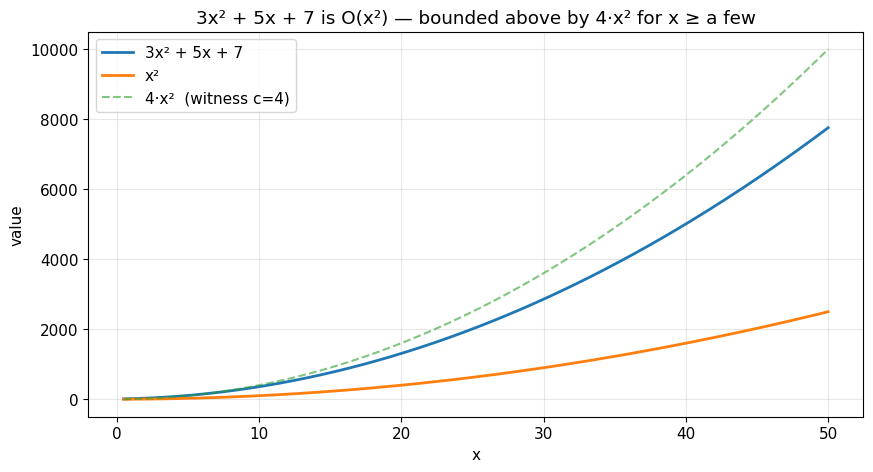

  for x ≥ 7: f(x) = 189 ≤ 196 = 4·x²  ✓


In [5]:
x = np.linspace(0.5, 50, 200)
f = 3 * x ** 2 + 5 * x + 7
g = x ** 2

plt.figure()
plt.plot(x, f, label='3x² + 5x + 7', linewidth=2)
plt.plot(x, g, label='x²', linewidth=2)
plt.plot(x, 4 * g, '--', label='4·x²  (witness c=4)', alpha=0.6)
plt.title('3x² + 5x + 7 is O(x²) — bounded above by 4·x² for x ≥ a few')
plt.xlabel('x'); plt.ylabel('value')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

# Find the witness k:
for x_val in range(1, 20):
    fv = 3*x_val**2 + 5*x_val + 7
    bound = 4 * x_val**2
    if fv <= bound:
        print(f'  for x ≥ {x_val}: f(x) = {fv} ≤ {bound} = 4·x²  ✓')
        break

### Proposition 10 — strict polynomial hierarchy

For `m < m'` in ℕ: `O(nᵐ) ⊊ O(nᵐ')`. **Strictly contained.**

Why strict? Because `nᵐ' ∉ O(nᵐ)`. The argument is the same as `x² ∉ O(x)` above: pick `x > c` and `xᵐ' / xᵐ = xᵐ'⁻ᵐ > 1` for any `c`, breaking the bound.

### Proposition 11 — every polynomial is O(its degree)

If `f` is a polynomial of degree `m`, then `O(f) = O(nᵐ)`.

Combined with Prop 10, this gives us **the polynomial hierarchy**:

$$O(1) \subsetneq O(n) \subsetneq O(n^2) \subsetneq O(n^3) \subsetneq \cdots \subsetneq O(n^m) \subsetneq \cdots$$

Every polynomial fits cleanly into one of these classes — the class of its leading term.

### Proposition 12 — log sits between constant and linear

$$O(1) \subsetneq O(\log n) \subsetneq O(n)$$

**Why `O(1) ⊊ O(log n)`:** for `x ≥ r` (where `r` is the log base), `1 ≤ log x`. Strict because `log` is unbounded while constants aren't.

**Why `O(log n) ⊊ O(n)`:** for `x ≥ 1`, `log x ≤ x`. Strict because `log` grows slower than `n` (no constant `c` makes `n ≤ c · log n` hold for all large `n`).

**Why we don't worry about the log base:** `logᵦ x = (1 / logₐ b) · logₐ x`, and `(1 / logₐ b)` is just a positive constant. By Prop 9(2), `O(log₂ n) = O(log₁₀ n) = O(ln n)`. So just write `O(log n)` and don't bother specifying the base.

## §4. The full hierarchy of common classes

Putting it all together (with `n log n` and exponential added):

$$O(1) \subsetneq O(\log n) \subsetneq O(n) \subsetneq O(n \log n) \subsetneq O(n^2) \subsetneq O(n^3) \subsetneq \cdots \subsetneq O(2^n)$$

Visually (note the log scale on the y-axis — without it, `2ⁿ` would crush everything else).

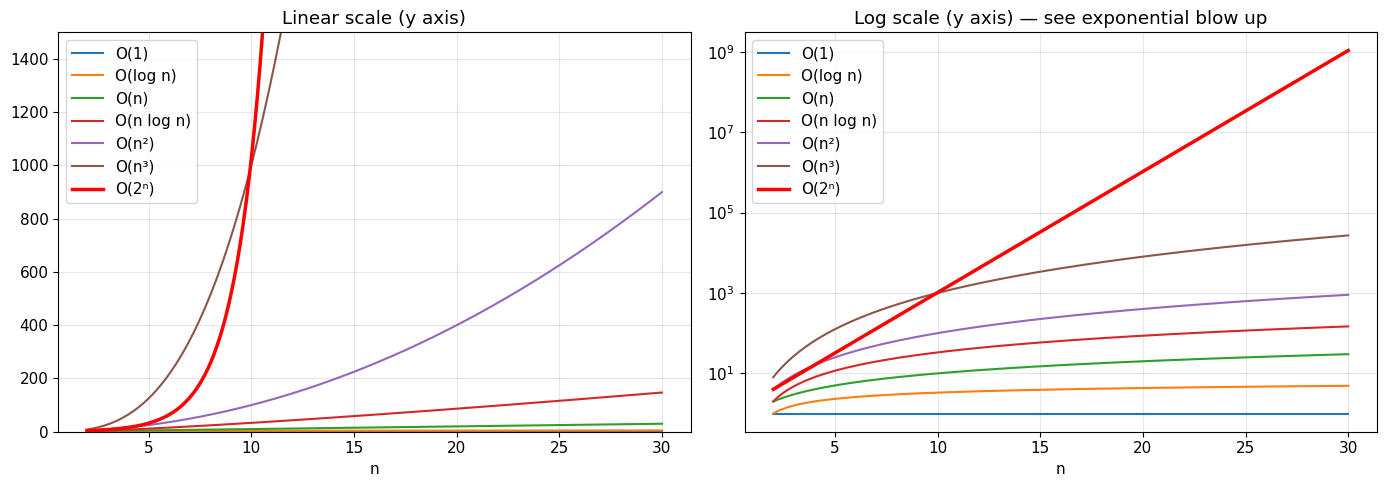

In [6]:
x = np.linspace(2, 30, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, scale, title in [(ax1, 'linear', 'Linear scale (y axis)'),
                          (ax2, 'log', 'Log scale (y axis) — see exponential blow up')]:
    ax.plot(x, np.ones_like(x),    label='O(1)')
    ax.plot(x, np.log2(x),         label='O(log n)')
    ax.plot(x, x,                   label='O(n)')
    ax.plot(x, x * np.log2(x),     label='O(n log n)')
    ax.plot(x, x ** 2,              label='O(n²)')
    ax.plot(x, x ** 3,              label='O(n³)')
    ax.plot(x, 2 ** x,              label='O(2ⁿ)', linewidth=2.5, color='red')
    ax.set_yscale(scale)
    ax.set_xlabel('n')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper left' if scale == 'log' else 'best')
    if scale == 'linear':
        ax.set_ylim(0, 1500)

plt.tight_layout()
plt.show()

**Two takeaways from the plots:**

1. **Linear scale:** `O(2ⁿ)` runs off the chart almost immediately. Even at `n = 30`, it's a billion. This is why exponential algorithms are usually unusable except for tiny inputs.
2. **Log scale:** the curves *look* like straight lines because `log(2ⁿ) = n log 2` is linear in `n`. Equally-spaced lines on log-scale = constant *ratio* of growth. The slopes tell you the asymptotic class.

## §5. Tractable vs intractable

Computer scientists make a pragmatic distinction:

- **Tractable** = polynomial complexity. There exists `m` such that the algorithm is `O(nᵐ)`. *Usable* in practice (though `m = 100` would still be impractical).
- **Intractable** = anything that grows faster than every polynomial. Exponential is the standard example. *Unusable* except for very small inputs.

**The famous open question P vs NP** asks whether certain problems (currently only solvable in exponential time) actually have polynomial-time algorithms we just haven't found. Most computer scientists believe `P ≠ NP` — that some problems are intrinsically intractable — but no one has proved it.

(The Ackermann function grows faster than every exponential. We don't worry about anything that bad in practice.)

## §6. Big Ω — lower bounds (§3.6)

`O(f)` is an *upper* bound: "`g` grows no faster than `f`." The mirror notion is a *lower* bound:

**`f` is `Ω(g)` iff `g` is `O(f)`.** Pronounced "f is big Omega of g."

Spelled out (Exercise 26): there exist `k, c ∈ ℝ⁺` with `c > 0` such that for all `x ≥ k`:

$$f(x) \ge c \cdot |g(x)|$$

**Use case:** when you want to say "this problem *can't* be solved faster than X." Sorting is `Ω(n)` because you have to look at every element at least once. (In comparison-based sorting, it's actually `Ω(n log n)` — a stronger result.)

## §7. Big Θ — tight bounds

**`f ∼ g`** (read: `f` is asymptotically equivalent to `g`) means `O(f) = O(g)`.

**`f` is `Θ(g)` iff `O(f) = O(g)`.** Pronounced "f is big Theta of g."

Equivalently (Exercise 28): there exist `c, c', k` with for all `x ≥ k`:

$$c \cdot |g(x)| \le f(x) \le c' \cdot |g(x)|$$

**Use case:** when you want to say "this algorithm runs in *exactly* this rate, no slower and no faster." `Θ` is `O ∩ Ω`. Stronger than either alone.

**Example:** if you can prove an algorithm is both `O(n log n)` (it never takes more than this many steps) and `Ω(n log n)` (some inputs force this many steps), you've shown it's `Θ(n log n)` — the tightest possible bound.

### Quick reference

| Notation | Says | Pronounced |
|:-:|:--|:--|
| `f ∈ O(g)` | `f` grows *no faster* than `g` | "f is big O of g" |
| `f ∈ Ω(g)` | `f` grows *no slower* than `g` | "f is big Omega of g" |
| `f ∈ Θ(g)` | `f` grows *at the same rate* as `g` | "f is big Theta of g" |

## §8. Exercises

## Exercise 21 — `O` is neither symmetric nor anti-symmetric

> Show that the 'grows at most as fast as' relation is neither symmetric nor anti-symmetric.

### Not symmetric — counter-example

**Symmetric** would mean: `f ∈ O(g)` implies `g ∈ O(f)`. Counter-example: take `f(x) = x` and `g(x) = x²`.

- `f ∈ O(g)`: yes — `c = 1, k = 1`, then `x ≤ 1 · x²` for `x ≥ 1`. ✓
- `g ∈ O(f)`: no — proven in §3.2.3 (no constant `c` makes `x² ≤ c · x` for all large `x`). ✗

So `f O-related to g` but `g` is *not* `O-related to f`. Not symmetric.

### Not anti-symmetric — counter-example

**Anti-symmetric** would mean: `f ∈ O(g)` *and* `g ∈ O(f)` implies `f = g`. Counter-example: take `f(x) = x` and `g(x) = 2x`.

- `f ∈ O(g)`: yes — `c = 1, k = 0`, `x ≤ 1 · 2x` for `x ≥ 0`. ✓
- `g ∈ O(f)`: yes — `c = 2, k = 0`, `2x ≤ 2 · x`. ✓
- But `f ≠ g` (one is `x`, the other is `2x`).

So `f` and `g` mutually relate but aren't equal. Not anti-symmetric.

**Conclusion:** `O` is a *pre-order* — reflexive and transitive (see Ex 22) — but not a partial order. ∎

## Exercise 22 — `O` is reflexive and transitive (for `ℝ⁺ → ℝ⁺`)

> Show that the 'grows at most as fast as' relation is reflexive and transitive for functions from `ℝ⁺` to `ℝ⁺`.

### Reflexive

**Claim:** `f ∈ O(f)` for any `f : ℝ⁺ → ℝ⁺`.

**Proof:** take `c = 1, k = 0`. For all `x ≥ 0`, `|f(x)| = f(x) ≤ 1 · f(x)`. ✓

(We use `|f(x)| = f(x)` because the codomain is `ℝ⁺` — outputs are non-negative.)

### Transitive

**Claim:** if `f ∈ O(g)` and `g ∈ O(h)`, then `f ∈ O(h)`.

**Proof:** by hypothesis there exist `c₁, k₁ ∈ ℝ⁺` such that for all `x ≥ k₁`, `|f(x)| ≤ c₁ · g(x)`. There also exist `c₂, k₂ ∈ ℝ⁺` such that for all `x ≥ k₂`, `|g(x)| ≤ c₂ · h(x)`.

Take `c = c₁ · c₂` and `k = max(k₁, k₂)`. For all `x ≥ k`:

$$|f(x)| \le c_1 \cdot g(x) = c_1 \cdot |g(x)| \le c_1 \cdot c_2 \cdot h(x) = c \cdot h(x)$$

(We used `g(x) = |g(x)|` because `g : ℝ⁺ → ℝ⁺`.)

Hence `f ∈ O(h)`. ✓ ∎

**Together with Exercise 21**, this shows `O` is a **pre-order**, not a partial order.

## Exercise 26 — characterise Ω

> Show that `f ∈ Ω(g)` iff there exist `k ∈ ℝ⁺` and `c ∈ ℝ⁺ \ {0}` such that for all `x ≥ k`, `f(x) ≥ c · |g(x)|`.

### Forward direction (`f ∈ Ω(g)` ⟹ the inequality holds)

By definition, `f ∈ Ω(g)` means `g ∈ O(f)`. By the definition of big-O, there exist `c' ∈ ℝ⁺` and `k ∈ ℝ⁺` such that for all `x ≥ k`:

$$|g(x)| \le c' \cdot f(x)$$

We need `c' > 0` for the next step (the case `c' = 0` would mean `g` is identically zero past `k`, which is a degenerate edge case we exclude). Set `c = 1/c' > 0`. Multiply both sides by `c`:

$$c \cdot |g(x)| \le f(x)$$

Done. ✓

### Reverse direction (inequality ⟹ `f ∈ Ω(g)`)

Suppose `f(x) ≥ c · |g(x)|` for all `x ≥ k`, with `c > 0`. Divide by `c`:

$$|g(x)| \le \frac{1}{c} \cdot f(x)$$

Setting `c'' = 1/c ∈ ℝ⁺ \ {0}`, we have `g ∈ O(f)`, i.e. `f ∈ Ω(g)`. ✓ ∎

**Practical reading:** `Ω(g)` is a lower bound — `f` is *at least as big as* `c · |g|` from some point onward.

## Exercise 27 — `∼` (where `f ∼ g` iff `O(f) = O(g)`) is an equivalence relation

> Show that `f ∼ g` defined by `O(f) = O(g)` is an equivalence relation.

Three conditions to check:

**Reflexive:** `O(f) = O(f)` is trivially true. So `f ∼ f`. ✓

**Symmetric:** if `O(f) = O(g)`, then `O(g) = O(f)` by the symmetry of set equality. So `f ∼ g` ⟹ `g ∼ f`. ✓

**Transitive:** if `O(f) = O(g)` and `O(g) = O(h)`, then `O(f) = O(h)` by transitivity of set equality. So `f ∼ g` and `g ∼ h` ⟹ `f ∼ h`. ✓

All three hold, so `∼` is an equivalence relation. The equivalence classes partition the function space — and each class is what we casually call "a complexity class." ∎

## Exercise 28 — characterise Θ

> Show that `f ∈ Θ(g)` iff there exist `c, c', k ∈ ℝ⁺` such that for all `x ≥ k`, `c · |g(x)| ≤ f(x) ≤ c' · |g(x)|`.

### Forward direction

`f ∈ Θ(g)` means `O(f) = O(g)`. By Proposition 8, this is equivalent to `f ∈ O(g)` *and* `g ∈ O(f)`.

- `f ∈ O(g)` gives `c', k₁` with `|f(x)| ≤ c' · |g(x)|` for `x ≥ k₁`.
- `g ∈ O(f)` (i.e. `f ∈ Ω(g)`) gives `c, k₂` with `c · |g(x)| ≤ f(x)` for `x ≥ k₂`.

Take `k = max(k₁, k₂)`. For `x ≥ k`, both inequalities hold:

$$c \cdot |g(x)| \le f(x) \le |f(x)| \le c' \cdot |g(x)|$$

Note: the chapter writes the right-hand side as `c' · g(x)` rather than `c' · |g(x)|` — this is fine when `g` is non-negative, which we typically assume for complexity functions. ✓

### Reverse direction

Given `c · |g(x)| ≤ f(x) ≤ c' · |g(x)|` for `x ≥ k`. The right inequality says `f ∈ O(g)`. The left says `f ∈ Ω(g)`. So `f ∈ Θ(g)`. ✓ ∎

**Practical reading:** `Θ` traps `f` between two scaled copies of `|g|`. The class is determined exactly.

## Exercise 29 — divisible-by-2-XOR-3 problem

> Consider the list of `i ∈ ℕ` divisible by 2 OR 3 but not both, in rising order. Given input `n`, find the n-th entry. What can you say about the complexity?

### Analyse the list

An integer `i` is in the list iff `i` is divisible by 2 XOR 3 — equivalently, divisible by 2 or 3 but not by 6.

The first entries: `2, 3, 4, 8, 9, 10, 14, 15, 16, 20, 21, 22, …`

**Density.** Among the first `N` natural numbers:

- `⌊N/2⌋` are divisible by 2.
- `⌊N/3⌋` are divisible by 3.
- `⌊N/6⌋` are divisible by 6 — counted in both groups, so subtract twice (once each, to remove from the list).

Count in the list among first `N`: `⌊N/2⌋ + ⌊N/3⌋ − 2⌊N/6⌋ ≈ N/2 + N/3 − N/3 = N/2`.

**So the n-th entry is approximately `2n`.**

### Upper bound — `O(n)`

Algorithm: scan natural numbers from `1`, count how many are in the list, stop at the n-th. Since we stop at roughly `2n`, this is `O(n)` lookups, each constant time (just modular arithmetic). **`O(n)` overall.**

### Lower bound — `Ω(log n)`

Whatever algorithm we use, the **output** itself has size `Θ(log n)` bits (since the n-th entry is approximately `2n`, requiring `log₂(2n)` bits to write). Just *producing* the answer takes at least `Ω(log n)` work. So the problem is `Ω(log n)`.

### Narrowing the gap

**Direct computation might give `O(log n)`** (or close):

- Out of every 6 consecutive integers, 4 are in the list (positions 2, 3, 4 in each block of 6 contributing 3, plus 6 contributing 0 — actually, in any block `6k, 6k+1, …, 6k+5`, the elements divisible by 2 are `6k, 6k+2, 6k+4`, but `6k` is also divisible by 6 so it's *out*; so just `6k+2, 6k+4` from divisibility-by-2. Divisible by 3: `6k, 6k+3` — but `6k` is out, so just `6k+3`. List entries in this block: `6k+2, 6k+3, 6k+4`. **Three** per block of six.)

Wait — that gives density `1/2`, matching our earlier estimate. So in each block of 6 we get 3 entries.

Given `n`, find the block: `block = (n − 1) // 3`. Position within block: `(n − 1) % 3 ∈ {0, 1, 2}` corresponds to entries `6·block + 2, 6·block + 3, 6·block + 4`.

**This gives the answer in `O(1)` arithmetic operations**, plus `O(log n)` to actually output the result.

**Final answer:** `O(log n)` (constant arithmetic plus output) and `Ω(log n)` (output lower bound). So the problem is `Θ(log n)`. **Gap closed.**

(Pre-figuring out the closed-form, the natural algorithm is `O(n)` by scanning. The closed form is the speed-up.)

In [7]:
# Verify the closed-form formula matches a direct scan.

def in_list(i):
    """Is i divisible by 2 XOR 3 (but not both)?"""
    return (i % 2 == 0) ^ (i % 3 == 0)

def scan(n):
    """O(n) — scan naturals to find the n-th entry."""
    count = 0
    i = 0
    while count < n:
        i += 1
        if in_list(i):
            count += 1
    return i

def closed_form(n):
    """O(log n) — direct computation."""
    block = (n - 1) // 3
    offset = (n - 1) % 3   # 0, 1, or 2
    return 6 * block + 2 + offset    # 6·block + 2, 6·block + 3, 6·block + 4

print(f'{"n":>3} | {"scan":>6} | {"closed-form":>11} | match?')
print('-' * 38)
for n in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 100, 1000]:
    s = scan(n)
    c = closed_form(n)
    print(f'{n:>3} | {s:>6} | {c:>11} | {"✓" if s == c else "✗"}')

  n |   scan | closed-form | match?
--------------------------------------
  1 |      2 |           2 | ✓
  2 |      3 |           3 | ✓
  3 |      4 |           4 | ✓
  4 |      8 |           8 | ✓
  5 |      9 |           9 | ✓
  6 |     10 |          10 | ✓
  7 |     14 |          14 | ✓
  8 |     15 |          15 | ✓
  9 |     16 |          16 | ✓
 10 |     20 |          20 | ✓
100 |    200 |         200 | ✓
1000 |   2000 |        2000 | ✓


## Summary

**The three notions:**

- **`f ∈ O(g)`** — upper bound. `f` grows no faster than `g`, up to a constant factor and beyond some point.
- **`f ∈ Ω(g)`** — lower bound. `f` grows no slower than `g`. Equivalently: `g ∈ O(f)`.
- **`f ∈ Θ(g)`** — tight bound. Both directions: `f ∈ O(g)` AND `f ∈ Ω(g)`.

**The hierarchy:**

$$O(1) \subsetneq O(\log n) \subsetneq O(n) \subsetneq O(n \log n) \subsetneq O(n^2) \subsetneq O(n^3) \subsetneq \cdots \subsetneq O(2^n)$$

All inclusions strict. Tractable = inside polynomial; intractable = outside.

**The four key simplification rules** (Proposition 9):

1. Positive scaling preserves `O`.
2. `O(c · f) = O(f)` for `c > 0`.
3. `f, g ∈ O(h)` ⟹ `f + g ∈ O(h)`.
4. `g ∈ O(f)` ⟹ `O(f + g) = O(f)`. **Drops lower-order terms.**

**The polynomial rule** (Proposition 11): every polynomial of degree `m` is `Θ(nᵐ)`.

**Next:** Quiz `08_quiz_chapter3.ipynb` to test all this. Plus a separate cheatsheet (`CHEATSHEET_COMPLEXITY.md`) with symbol pronunciations and the recognition rules at-a-glance.